In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import easyocr as ocr
import re
import json
import torch

In [5]:
curr_dir = "../Images"
all_images = os.listdir(curr_dir)

In [ ]:
image = os.path.join(curr_dir,all_images[3])
img = cv2.imread(image)
reader = ocr.Reader(['en'],gpu=torch.cuda.is_available())
res = reader.readtext(img)
res

[([[np.int32(234), np.int32(86)],
   [np.int32(392), np.int32(86)],
   [np.int32(392), np.int32(138)],
   [np.int32(234), np.int32(138)]],
  'WHZLE',
  np.float64(0.5589058661110933)),
 ([[np.int32(237), np.int32(125)],
   [np.int32(391), np.int32(125)],
   [np.int32(391), np.int32(167)],
   [np.int32(237), np.int32(167)]],
  'FOODS',
  np.float64(0.9998875642142653)),
 ([[np.int32(230), np.int32(196)],
   [np.int32(328), np.int32(196)],
   [np.int32(328), np.int32(226)],
   [np.int32(230), np.int32(226)]],
  'SHARON',
  np.float64(0.9990610660303846)),
 ([[np.int32(336), np.int32(198)],
   [np.int32(376), np.int32(198)],
   [np.int32(376), np.int32(226)],
   [np.int32(336), np.int32(226)]],
  'RD _',
  np.float64(0.7614262371894397)),
 ([[np.int32(281), np.int32(261)],
   [np.int32(373), np.int32(261)],
   [np.int32(373), np.int32(277)],
   [np.int32(281), np.int32(277)]],
  'TORTILLA" $',
  np.float64(0.9152380107711172)),
 ([[np.int32(205), np.int32(279)],
   [np.int32(245), np.int3

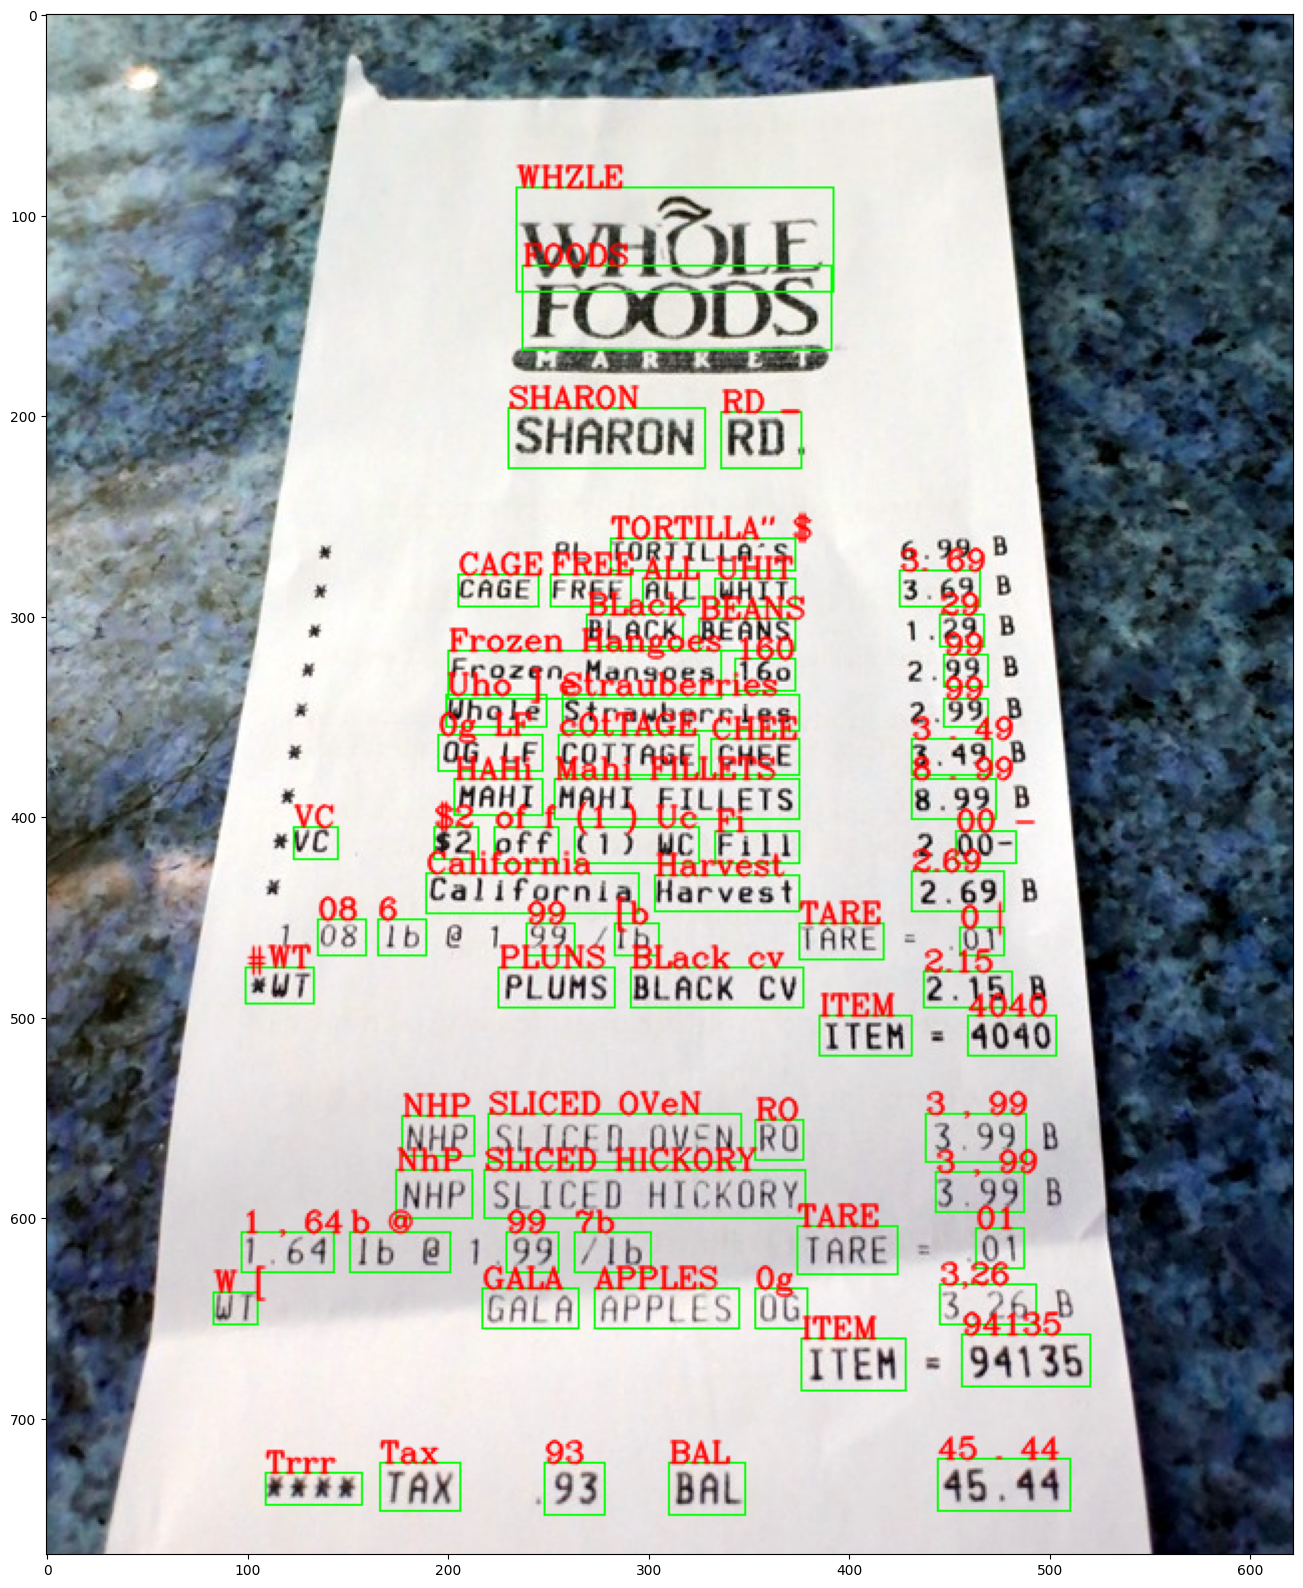

In [81]:
img = cv2.imread(image)
for detection in res:
    top_left = tuple(int(val) for val in detection[0][0])
    bottom_right = tuple(int(val) for val in detection[0][2])
    text = detection[1]
    img = cv2.rectangle(img,top_left,bottom_right,(0,255,0),1)
    img = cv2.putText(img,text,top_left,cv2.FONT_HERSHEY_COMPLEX,0.5,(255,0,0),1,cv2.FONT_ITALIC)
plt.figure(figsize=(20,20))
plt.imshow(img)
plt.show()

In [ ]:
json_path = os.path.join("..","output")
output_img = os.path.join("..","Output_images")

In [190]:
def get_details(lines):

    # store name
    temp = lines[:10]
    store_name = "Unknown Store"

    ignore_keywords = [
        "receipt", "survey", "save", "scan",
        "thank", "www", "phone", "chance"
    ]

    for item in temp:
        cleaned = item.strip()

        if any(word in cleaned.lower() for word in ignore_keywords):
            continue

        if len(cleaned.split()) <= 4 and re.search(r'[A-Za-z]', cleaned):
            store_name = cleaned
            break

    # date Extraction
    date = None
    date_pattern = r'\d{2}[/-]\d{2}[/-]\d{2,4}'


    for line in lines:
        clean_line = line.replace("O", "0")

        match = re.search(date_pattern, clean_line)
        if match:
            date = match.group()
            break


    # item extraction
    items = []

    ignore_words = [
        "subtotal", "tax", "total", "cash",
        "change", "tend", "payment",
        "validation", "account", "store",
        "trans", "manager", "approval"
    ]
    
    for i in range(len(lines)):
        
        current_token = lines[i].strip()
    
        # skip unwanted keywords
        if any(word in current_token.lower() for word in ignore_words):
            continue
    
        # must contain alphabets
        if not re.search(r'[A-Za-z]', current_token):
            continue
    
        price = None
    
        # check next 2 tokens
        for j in range(i+1, min(i+3, len(lines))):
            next_token = lines[j].strip()
    
            # only decimal prices
            match = re.fullmatch(r'\d+\.\d{1,2}', next_token)
    
            if match:
                price = match.group()
                break
    
        if price:
            items.append({
                "name": current_token,
                "price": price
            })

    # total amount extraction
    total_amount = None
    
    # first search exact TOTAL
    for i in range(len(lines)-1):
        current_line = lines[i].lower()
    
        if current_line.strip() == "total":
            next_line = lines[i+1]
    
            amount = re.findall(r'^\d+\.\d{1,2}$', next_line)
    
            if amount:
                total_amount = float(amount[0])
                break
    
    
    # fallback - subtotal/grand total
    if total_amount is None:
        for i in range(len(lines)-1):
            current_line = lines[i].lower()
    
            if "subtotal" in current_line:
                next_line = lines[i+1]
    
                amount = re.findall(r'\d+\.?\d*', next_line)
    
                if amount:
                    total_amount = float(amount[0])
                    break

    receipt_data = {
        "store_name": store_name,
        "date": date,
        "items": items,
        "total_amount": total_amount
    }

    return receipt_data


def extract_text(res, name):

    all_lines = []

    # EasyOCR output -> (bbox, text, confidence)
    for detection in res:
        text = detection[1]
        all_lines.append(text)
        
    ocr_lines = [
        line.strip()
        for line in all_lines
        if line.strip()
    ]

    # structured extraction
    data = get_details(ocr_lines)

    file_name = name.split(".")[0]
    path = os.path.join(json_path,file_name+".json")
    
    with open(path, "w") as f:
        json.dump(data, f, indent=4)

In [ ]:
reader = ocr.Reader(['en'],gpu=torch.cuda.is_available())

for image_name in all_images:
    path = os.path.join(curr_dir,image_name)
    img = cv2.imread(path)

    results = reader.readtext(img)
    for detection in results:
        top_left = tuple(int(val) for val in detection[0][0])
        bottom_right = tuple(int(val) for val in detection[0][2])
        text = detection[1]
        # create rectangle around the text 
        img = cv2.rectangle(img,top_left,bottom_right,(0,255,0),1)
        img = cv2.putText(img,text,top_left,cv2.FONT_HERSHEY_COMPLEX,0.5,(255,0,0),1,cv2.FONT_ITALIC)        
    output_img = os.path.join("..","Output_images",image_name)
    # save the image in output folder
    cv2.imwrite(output_img,img)
    extract_text(results,image_name)

In [201]:
total_spend = 0
transactions = 0
path = os.path.join("..","output")
files = os.listdir(os.path.join("..","output"))[2:]
for file in files:
    with open(f"{path}/{file}") as f:
        data = json.load(f)
        
        if data["total_amount"]:
            total_spend += float(data["total_amount"])
            transactions += 1

print("Total Spend:", round(total_spend,2))
print("Transactions:", transactions)

Total Spend: 71312.81
Transactions: 117
